<div align="center">

#  PROJEKT DATA SCIENCE

## Analiza Jakości Powietrza dla Miasta Poznań

### ~ Porównanie modeli predykcyjnych Linear Regression oraz CatBoost ~

<br>

**Autor:** Jerzy Marcin Urbański

</div>

---

## Cel projektu

Głównym celem projektu jest porównanie jakości predykcji oraz skuteczności dwóch modeli uczenia maszynowego nadzorowanego:

* **Linear Regression**
* **CatBoost Regressor**

Modele zostaną wytrenowane na przygotowanym zbiorze danych, a następnie ocenione przy użyciu odpowiednich metryk regresyjnych.

Analiza wyników pozwoli:

* określić dokładność obu modeli,

* porównać ich zdolność do generalizacji,

* wskazać model zapewniający lepsze prognozy jakości powietrza,

* ocenić wpływ zastosowanej metody na końcową jakość predykcji.


---
## Źródła danych 
* Główny Inspektorat Ochrony Środowiska - https://powietrze.gios.gov.pl/pjp/archiv
* ECMWF Copernicus Climate Change Service - https://era5downloader.org/

---

## Plan realizacji

### 1. Wczytanie i wstępne przygotowanie danych.
* Wczytanie dancyh surowch
* Wstępna obróbka danych surowych
* Utworzenie wspólnego DataFrame MAIN
* Walizadacja, weryfikacja struktury i satstystyka opisowa MAIN

### 2. Diagnostyka / EDA / Agregacja
* SPrawdzenie duplikatów
* Sprawdzenie brakujacych wartości
* EDA + Raport porfilowy
* Analiza Skońsności
* Analizy Outlierów
* Badanie Korelacji 

### 3. Transformacja Danych
* Feature engeniring
* Preprocessing dla Linear Regression

### 4. Budowa modeli + metryki

* Linear Regression
* CatBoost Regressor

### 5. Porównanie wyników

* Analiza błędów
* Interpretacja rezultatów
* Wnioski końcowe

---

## Oczekiwany rezultat

Projekt ma na celu określenie, który z badanych modeli lepiej radzi sobie z prognozowaniem jakości powietrza na podstawie czeteroletnich danych meteorologicznych oraz jakie korzyści daje zastosowanie bardziej zaawansowanych metod uczenia maszynowego w porównaniu z klasyczną regresją liniową.


<hr style="border: none; border-top: 5px dotted black;">

## Modele ML - Opis i Teoria 

### 1. Linear Regression 

Regresja liniowa (Linear Regression) jest jednym z podstawowych algorytmów uczenia nadzorowanego (Supervised Learning), wykorzystywanym do modelowania zależności pomiędzy zmienną zależną (zmienną objaśnianą) a jedną lub wieloma zmiennymi niezależnymi (zmiennymi objaśniającymi).
Głównym celem modelu jest znalezienie takiej funkcji liniowej, która w możliwie najlepszy sposób opisuje zależność występującą w danych oraz pozwala przewidywać wartości zmiennej docelowej dla nowych obserwacji.
W przypadku regresji wielowymiarowej model można zapisać w postaci:

$$
y = aX + b
$$
gdzie:
- $y$ - wektor cech zależnych (target)
- $X$ - Macierz cech (features)
- $a$ - wektor współczynników regresji 
- $b$ - wektor błędów 


### 2. CatBoost Regression 

CatBoost Regression jest algorytmem uczenia nadzoerowanego przeznaczonym do dla przewidywania regresji, czyli wartości liczbowych. Model należy do rodziny algorytmó∑ Gradient Boosting Decision Trees. CatBoost buduje wiele drzew decyzyjnych sekwencyjnie, gdzie każde kolejne drzewo uczy się na błędach popełnionych przez poprzednie drzewa. Dzięki temu model stopniowo poprawia jakość predykcji i jest w stanie uchwycić złożone, nieliniowe zależności występujace w danych.

**Zasada Działania**

CatBoost wykorzystuje technikę *Gradien Boostingu*, które polega na budowaniu zespołu wielu słabych modeli (drzew decyzyjnych). Każde nowe drzewo nie przewiduje wartości docelowej od poczatku , lecz stara się skorygować będy prprzedniego modelu.

Proces działania: 
1. Pierwsze drzewo
2. Model wykonuje predykcję na jego podstawie.
3. Obliczane sa błędy predykcji (reszty)
4. Budowane jest kolejne drzewo uczace się tych błędów i minimalizowaniu funkcji straty.
5. Predykcje nowego drzewa sa dodawane do poprzednich wyników.
6. Proces jest powtarzany , aż do osiagnięcia zadanej liczby drzew lub spełnienia kryterium zatrzymania.

## Metryki Walidacyjne

### 1. MAE

Średni bład bezwzględny określa przeciętna wartoś odchylenia prognozy od wartości rzeczywistej obserwacji.
Dla MAE idelnym wynikiem jest "0" , im niższa wartosć MAE , tym lepsza jakość predykcji. Metryka jest odporna na pojedyńcze wartości odstajace (outliery). Stabilna i podawana w jednostkach danych, co ułatwia interpretacje. Należy ja stosowac, gdy wszyskie błędy sa równie ważne.


$$
MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|
$$
gdzie:

- $n$ – liczba obserwacji,
- $y_i$ – rzeczywista wartość dla i-tej obserwacji,
- $\hat{y}_i$ – wartość przewidywana przez model dla i-tej obserwacji,

### 2. MSE 

Średni bład kwadratowy mierzy śdrenia wartość kwadratów będów predykcji. MSE silnie karze duże błędy, po przez podniesienie do kwadratu. Zaleta tej metryki jest to, że uwzględnia  wpływ dużcyh odchyleń i przydaje się do optymalizajci modeli. 
$$
MAE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$
gdzie:
- $n$ – liczba obserwacji,
- $y_i$ – rzeczywista wartość dla i-tej obserwacji,
- $\hat{y}_i$ – wartość przewidywana przez model dla i-tej obserwacji,

### 3. RMSE

PIerwiastek średniego będu kwadratowego (Root Mean Squared Error) informuje o przeciętnym błędzie predykcji. Różni się od MAE tym, że duże błędy maja większy wpływ na tę metrykę i sa bardziej zauważalne niż przy wynikach MAE.
$$
MAE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

gdzie:
- $n$ – liczba obserwacji,
- $y_i$ – rzeczywista wartość dla i-tej obserwacji,
- $\hat{y}_i$ – wartość przewidywana przez model dla i-tej obserwacji,

### 4. R2

Współczynnik determinacji określa jaka część wariancji targetu wyjaśnia model. R2 na poziomie 1 to idelane dopasowanie, a R2 równe 0 model nie wyjasnie lepiej zmienności danych niż średnia. Zaleta tej metryki jest czytelnosć skutecznosci i poprawności działania modelu i pozwala go szybko ocenic.

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$
gdzie:

- $y_i$ – rzeczywista wartość zmiennej docelowej dla i-tej obserwacji  
- $\hat{y}_i$ – wartość przewidywana przez model  
- $\bar{y}$ – średnia wartość zmiennej docelowej  
- $n$ – liczba obserwacji  

<hr style="border: none; border-top: 5px dotted black;">

Importy Bibliotek wraz z ich opisem 

In [13]:
# Biblioteka do pracy z danymi tabelarycznymi (DataFrame), umożliwia łatwe filtrowanie, grupowanie i przekształcanie danych. 
# Używana głównie do analizy danych, czyszczenia danych oraz wczytywania/zapisywania plików (CSV, Excel, SQL).
import pandas as pd

# ### numpy
# Podstawowa biblioteka do obliczeń numerycznych w Pythonie, oferująca wydajne operacje na tablicach wielowymiarowych. 
# Wykorzystywana do obliczeń matematycznych, statystycznych oraz jako fundament dla innych bibliotek analitycznych.
import numpy as np

# ### os
# Biblioteka standardowa do interakcji z systemem operacyjnym, umożliwia pracę z plikami i katalogami oraz zmiennymi środowiskowymi. 
#Używana m.in. do automatyzacji operacji na plikach i zarządzania ścieżkami.
import os

# ### matplotlib
# Biblioteka do tworzenia wykresów i wizualizacji danych w Pythonie. Pozwala generować różne typy wykresów (liniowe, słupkowe, histogramy) 
# oraz dostosowywać ich wygląd.
import matplotlib.pyplot as plt

# ### seaborn
# Rozszerzenie matplotlib, które upraszcza tworzenie estetycznych i statystycznych wizualizacji danych. 
# Umożliwia szybkie generowanie wykresów takich jak heatmapy, wykresy rozkładu czy zależności między zmiennymi.
import seaborn as sns

# ### ydata_profiling
# Biblioteka do automatycznej analizy eksploracyjnej danych (EDA), generująca szczegółowe raporty o zbiorze danych. 
# Pokazuje statystyki, brakujące wartości, korelacje i potencjalne problemy w danych.
from ydata_profiling import ProfileReport

# ### IPython.display
# Moduł umożliwiający wyświetlanie różnych typów treści w notebookach (HTML, obrazy, wideo). 
#  Używany do wzbogacania prezentacji wyników analiz i tworzenia interaktywnych raportów.
from IPython.display import IFrame

# Moduł do obsługi ścieżek plików
from pathlib import Path

# Moduł do obliczania macirzy korelacji miedzy zmiennymi DataFrame , zarówno numerycznymi jak i kategorycznymi 
from phik import phik_matrix

Sekcja bibliotek ML

In [15]:

# Funkcja do podziału danych na zbiory treningowe i testowe.
from sklearn.model_selection import train_test_split

# Narzędzie do stosowania różnych transformacji dla różnych kolumn danych.
from sklearn.compose import ColumnTransformer

# Umożliwia łączenie etapów przetwarzania danych i modelowania w jeden proces.
from sklearn.pipeline import Pipeline

# Narzędzie do uzupełniania brakujących wartości w danych.
from sklearn.impute import SimpleImputer

# OneHotEncoder – zamienia zmienne kategoryczne na postać numeryczną (0/1).
# StandardScaler – standaryzuje cechy do średniej 0 i odchylenia standardowego 1.
# FunctionTransformer – pozwala stosować własne funkcje transformujące dane.
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

# LinearRegression – klasyczny model regresji liniowej.
# Ridge – regresja liniowa z regularyzacją L2 ograniczającą przeuczenie.
from sklearn.linear_model import LinearRegression, Ridge

# mean_absolute_error – średni błąd bezwzględny modelu.
# mean_squared_error – średni błąd kwadratowy modelu.
# r2_score – współczynnik determinacji R² oceniający jakość dopasowania.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Narzędzie do walidacji krzyżowej i oceny stabilności modelu.
from sklearn.model_selection import cross_val_score

# Prosty model bazowy generujący predykcje bez uczenia zależności z danych.
from sklearn.dummy import DummyRegressor

# Model boostingowy dobrze radzący sobie z danymi kategorycznymi bez rozbudowanego preprocessing'u.
from catboost import CatBoostRegressor

# Wrapper umożliwiający przewidywanie wielu zmiennych docelowych jednocześnie.
from sklearn.multioutput import MultiOutputRegressor


## STEP 1. Wczytanie i wstępne przygotowanie surowych danych
        [ LOAD DATA + PREPROCESSING NA WSTĘPNYCH DANYCH ]
Import danych z plików csv , ostateczne sprawdznie oraz potrzebna agregacja do ostatecznej wersji.

In [18]:
# przygotowanie ścieżki 
project_dir = Path.cwd()

### 1.1. TABELE DANE POGODOWE - weather_pz

#### 1.1.1. Import wszyskich plików do odpowiednich zmiennych

In [21]:
# import wszyskich plików do odpowiednich zmiennych 

w_pz_2021 = pd.read_csv(project_dir/'0_ready_raw_data'/'weather_pz_2021.csv')
w_pz_2022 = pd.read_csv(project_dir/'0_ready_raw_data'/'weather_pz_2022.csv')
w_pz_2023 = pd.read_csv(project_dir/'0_ready_raw_data'/'weather_pz_2023.csv')
w_pz_2024 = pd.read_csv(project_dir/'0_ready_raw_data'/'weather_pz_2024.csv')

In [22]:
# szybkie sprawdznie 

display(w_pz_2021.head(2))
# display(w_pz_2022.head(2))
# display(w_pz_2023.head(2))
# display(w_pz_2024.head(2))

,Unnamed: 0,time,latitude,longitude,number,step,surface,valid_time,u10,v10,t2m,blh,sp,tcc
0,0,2021-01-01 00:00:00,52.5,17.0,0,0 days,0.0,2021-01-01 00:00:00,-2.422302,2.071365,270.71216,147.41356,99757.56,0.931488
1,1,2021-01-01 06:00:00,52.5,17.0,0,0 days,0.0,2021-01-01 06:00:00,-2.407318,2.537811,270.98218,250.48758,99785.56,1.000000


#### 1.1.1. Połaczenie w jedne DataFrame

In [24]:
w_df = pd.concat([w_pz_2021,w_pz_2022,w_pz_2023,w_pz_2024], axis=0 , ignore_index=True)

#### 1.1.2. Agregacja danych do postaci uniwersalnego DataFrame 

In [26]:
# przypisanie odpowiedniego id miasta [city] wg współrzędnych

w_df['city'] = w_df['longitude'].map({17.0 : 'PZ'})

In [27]:
# Selekscja kolumn do usunięcia 

# print(w_pz_2021['step'].nunique()) # kolumna ma jeden wynik -> usunać
# print('-'*140)
# print(w_pz_2022['surface'].nunique()) # kolumna ma jeden wynik -> usunać
# print('-'*140)
# print(w_pz_202[w_ld_2004["time"] != w_ld_2004["valid_time"]]) # kolumna 'valid_time' powtrza wartosci 'time' -> usunać 
# print('-'*140)
# print(w_ld_2012['number'].nunique())

In [28]:
# usunięcie niepotrzebnych kolumn ['Unnamed: 0','latitude','longitude','step','surface','valid_time']

w_df = w_df.drop(['Unnamed: 0','latitude','longitude','step','surface','valid_time','number'], axis=1)

In [29]:
# Zamiana typu danych object z kolumny 'time' na date_time

w_df['time'] = pd.to_datetime(w_df['time'])

Obliczenie prędkości wiatru ze zmiennych u10 & v10 ze wzoru tj z równania pitagorasa
- zmienna u10 => prędkość wiatru zachodniego 
- zmienna v10 => prędkość wiartu północnego 

$$
v_w = \sqrt{u_{10}^2 + v_{10}^2}
$$


In [31]:
# przeliczenie prędkości wiatru 'v_w' i dodanie jako nowa kolumna z tymi wartościami

w_df['v_w'] = np.sqrt(w_df['u10']**2 + w_df['v10']**2)

In [32]:
# Usunicie zbędnych kolumn u10, 'v10' jako składowe wiatru nie potrzebne do dalszych analiz.

w_df = w_df.drop(['u10','v10'], axis=1)

In [33]:
# ułożenie kolejnosci kolumn [info data | zmienne pogodowe] 

col_order = ['city','time','v_w','t2m','blh','sp','tcc']
w_df = w_df[col_order]

#### 1.1.3. PODSUMOWANIE DANE POGOWE 
#### OPIS ZMIENNYCH

| Zmienna | Opis                                              | Jednostka       |
| --------|---------------------------------------------------|-----------------|
| `'u10'` | predkosc wiatru z kierunku                        | `[ m/s ]`       |
| `'v10'` | prędkość wiatru z kierunku                        | `[ m/s ]`       |
| `'v_w'` | rzeczywista prędkość wiatru                       | `[ m/s ]`       |
| `'t2m'` | temperatura powietrze 2m nad poziomem powierzchni | `[ Kelwin ]`    |
| `'blh'` | WYSOKOŚĆ WARSTWY GRANICZNEJ                       | `[ m ]`         |
| `'sp'`  | CIŚNIENIE                                         | `[ Pa ]`        |
| `'tcc'` | CAŁKOWITE ZACHMURZENIE                            | `[ 0-1 ] [ % ]` |

    

### 1.2. TABELE CAŁKOWITE OPADY - total_precipitation

#### 1.2.1. Import wszyskich plików do odpowiednich zmiennych 

In [37]:
tp_pz_2021 = pd.read_csv(project_dir/'0_ready_raw_data'/'total_precipitation_pz_2021.csv')
tp_pz_2022 = pd.read_csv(project_dir/'0_ready_raw_data'/'total_precipitation_pz_2022.csv')
tp_pz_2023 = pd.read_csv(project_dir/'0_ready_raw_data'/'total_precipitation_pz_2023.csv')
tp_pz_2024 = pd.read_csv(project_dir/'0_ready_raw_data'/'total_precipitation_pz_2024.csv')

In [38]:
# szybkie sprawdznie 

# print(tp_pz_2021.info())
# print('^'*140)
display(tp_pz_2021.head(2))
# display(tp_pz_2022.head(2))
# display(tp_pz_2023.head(2))
# display(tp_pz_2024.head(2))

,Unnamed: 0,time,step,latitude,longitude,number,surface,valid_time,tp
0,0,2020-12-31 18:00:00,0 days 01:00:00,52.5,17.0,0,0.0,2020-12-31 19:00:00,NaN
1,1,2020-12-31 18:00:00,0 days 02:00:00,52.5,17.0,0,0.0,2020-12-31 20:00:00,NaN


####  1.2.2. Połaczenie wszystkich Data Frame w jeden pogodowy 

In [40]:
tp_df = pd.concat([tp_pz_2021,tp_pz_2022,tp_pz_2023,tp_pz_2024], axis=0 , ignore_index=True).reset_index()

#### 1.2.3. - Agregacja danych do postaci uniwersalnego DataFrame 

In [42]:
# usuwamy zbedne kolumny, nie potrzebne do analizy i dalszej agregacji 

tp_df = tp_df.drop(['Unnamed: 0','time','step','number','surface','index'], axis=1) 

In [43]:
# Zamiana kolumn z data i czasem na typ danych date_time

tp_df['valid_time'] =  tp_df['valid_time'].apply(pd.to_datetime)

# Usuwamy niepotrzebne punkty pomiarowe z innych godzin 'valid_time' niż 00:00, 06:00, 12:00, 18:00 każdego dnia

tp_df = tp_df[tp_df['valid_time'].dt.hour.isin([0, 6, 12, 18])]

# zamieniamy nazwę valid_time na time , aby pasowała do poprzedniego DataFrame dane pogodowe i mozliwosci ich połaczenia

tp_df = tp_df.rename(columns={'valid_time':'time'})

In [44]:
# sprawedzenie wartosci longitude dla wybranych miast 
tp_df['longitude'].unique()

array([17.])

In [45]:
# przypisanie skrótu miasta w nowej kolumnie 'city' + usuniecie niepotrzebnej kolu

tp_df['city'] = tp_df['longitude'].map({17.0 : 'PZ'})

In [46]:
# usuwamy zbedne kolumny lognitude i 

tp_df = tp_df.drop(['longitude','latitude'], axis=1) 

In [47]:
# Sprawdzenie 
# tp_df.describe()

#### 1.2.4. PODSUMOWANIE PKT. 1.2. CAŁKOWITE OPADY  
### OPIS ZMIENNYCH

| Zmienna  | Opis                                                   |
| :------- | :----------------------------------------------------- |
| `'PZ'`   | MIASTO ZAPISANE W SYMOBOLEM                            |
|          | `PZ = Poznań`                                          |
|          | `LD = Łódź`                                            |
| `'time'` | DATA.GODZINA                                           |
| `'tp'`   | CAŁKOWITE OPADY / jednostka `[ m ]`  |


### 1.3. TABELE INWERSJE - inwersja-pz

#### 1.3.1. Import wszystich plikow do odpowiednich zmienych 

In [51]:
i_pz_2021 = pd.read_csv(project_dir/'0_ready_raw_data'/'inwersja_pz_2021.csv')
i_pz_2022 = pd.read_csv(project_dir/'0_ready_raw_data'/'inwersja_pz_2022.csv')
i_pz_2023 = pd.read_csv(project_dir/'0_ready_raw_data'/'inwersja_pz_2023.csv')
i_pz_2024 = pd.read_csv(project_dir/'0_ready_raw_data'/'inwersja_pz_2024.csv')

In [52]:
# szybkie sprawdzenie 

# print(i_pz_2021.info())
# print('^'*140)
display(i_pz_2021.head(2))
# display(i_pz_2022.head(2))
# display(i_pz_2023.loc[i_pz_2023['time']=='2023-04-23 18:00:00'])
# display(i_pz_2024.head(2))

,Unnamed: 0,time,isobaricInhPa,latitude,longitude,number,step,valid_time,t
0,0,2021-01-01 00:00:00,1000.0,52.5,17.0,0,0 days,2021-01-01 00:00:00,272.07275
1,1,2021-01-01 00:00:00,925.0,52.5,17.0,0,0 days,2021-01-01 00:00:00,272.81152


#### 1.3.2. Łaczymy wszyskie tabele do jednego DataFrame

In [54]:
i_df = pd.concat([i_pz_2021, i_pz_2022, i_pz_2023, i_pz_2024],  axis=0, ignore_index=True)

#### 1.3.3. Agregacja danych do postaci uniwersalnego datasetu.

In [56]:
# przypisanie skrótu miasta w nowej kolumnie 'city' + usuniecie niepotrzebnej kolu

i_df['city'] = i_df['longitude'].map({17.0 : 'PZ'})

In [57]:
# Zamiana typu danych kolumny 'time' na date_time

i_df['time'] = pd.to_datetime(i_df['time'])

In [58]:
## USTALENIE INWERSJI 0/1 NA PODSTAWIE RÓŻNICY TEMPERATURY NA WYSOKOŚĆI Z CIŚNIENEIM 1000 A 925

# Rozdzielam na dwa DataFrame 
df_925 = i_df[i_df['isobaricInhPa'] == 925][['time','t','city']].rename(columns = {'t': 't_925'})
df_1000 = i_df[i_df['isobaricInhPa'] == 1000][['time','t','city']].rename(columns = {'t': 't_1000'})

# Łaczymy oba df, w jeden do obliczenia różnicy
i_df_delta = pd.merge(df_925, df_1000, how='left', on=['time','city'])

# kolumna t_delta = podaje rożnice w stopniach 
i_df_delta['t_delta'] = i_df_delta['t_1000']-i_df_delta['t_925']
i_df_delta['inversion_0/1'] = [1 if e > 0 else 0 for e in i_df_delta['t_delta']]

# i_df_delta.head()

In [59]:
# usuwamy nie potrzebne kolumny do dalszej analizy 

i_df_delta = i_df_delta.drop(['t_925','t_1000','t_delta'],axis=1)

In [60]:
# Sprawdzenie poprawnosci inwersja_DataFrame gotowego do megre do głwnego DataFrame

display(i_df_delta.iloc[1005:1010])
print('^' * 140) 
display(i_df_delta['city'].unique())
display(i_df_delta['inversion_0/1'].unique())
print('^' * 140) 
# display(i_df_delta.info())

,time,city,inversion_0/1
1005,2021-09-09 06:00:00,PZ,0
1006,2021-09-09 12:00:00,PZ,1
1007,2021-09-09 18:00:00,PZ,1
1008,2021-09-10 00:00:00,PZ,0
1009,2021-09-10 06:00:00,PZ,0


^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


array(['PZ'], dtype=object)

array([0, 1])

^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


#### 1.3.4. PODSUMOWANIE PKT. 1.3. Inwersje

#### OPIS ZMIENNYCH

| Zmienna          | Opis                                                     |
| :--------------- | :------------------------------------------------------- |
| `'PZ'`           | MIASTO ZAPISANE W SYMOBOLEM (`PZ = Poznań`, `LD = Łódź`) |
| `'time'`         | DATA GODZINA                                             |
| `'inverion_0/1'` | inwersja_0 = NIE MA / inwerja_1 = JEST                   |


### 1.4. Tabele Zanieczyszczeń Powietrza - data_polution_

#### 1.4.1. Import wszystich plikow do odpowiednich zmienych 

In [64]:
polution_2021 = pd.read_csv(project_dir/'0_ready_raw_data'/'data_polution_2021')
polution_2022 = pd.read_csv(project_dir/'0_ready_raw_data'/'data_polution_2022')
polution_2023 = pd.read_csv(project_dir/'0_ready_raw_data'/'data_polution_2023')
polution_2024 = pd.read_csv(project_dir/'0_ready_raw_data'/'data_polution_2024')
# SZYBKIE SPRAWDZENIE 
display(polution_2021.head(1))
# display(polution_2022.head(1))
# display(polution_2023.head(1))
# display(polution_2024.head(1))

,Unnamed: 0,Date_time,LdLodz_PM10,WpPozn_PM10,LdLodz_PM25,WpPozn_PM25,LdLodz_NO2,WpPozn_NO2,LdLodz_CO,WpPozn_CO
0,0,2021-01-01 01:00:00,44.0,NaN,28.0,NaN,NaN,NaN,0.401,0.55772


#### 1.4.2. Połaczenie obu datasetów do jednego DataFrame

In [66]:
# Połczenie obu lat w jeden chronologiczny dataset

polution_df = pd.concat([polution_2021,polution_2022,polution_2023, polution_2024],  axis=0, ignore_index=True)

#### 1.4.3. Agregeacja danych do postaci uniwersalnego DataFrame

In [68]:
# usuwamy zbedne kolumny, nie potrzebne do analizy i dalszej agregacji 

polution_df = polution_df.drop(['Unnamed: 0'], axis=1) 

In [69]:
# Zmiana typu danych kolumny 'Date_time' ze str na date_time 

polution_df['Date_time'] = pd.to_datetime(polution_df['Date_time'])

# Zamiania nazwy kolumny Date_time na 'time', aby dopasować do pozostałych kolumn z 'time'

polution_df = polution_df.rename(columns={'Date_time' : 'time'})

In [70]:
# Usunięcnie nie potrzebnych godzin pomiaru w ciagu każdej doby, pozostawiamy tylko 
# 00:00 ; 06:00 ; 12:00 ; 18:00

polution_df = polution_df[polution_df['time'].dt.hour.isin([0, 6, 12, 18])]

In [71]:
# Reset indexu dla polution_df

polution_df = polution_df.reset_index(drop=True)

In [72]:
# Rozbijamyu polution_df na dwa DataFramy , dane Łódź oraz dane Poznań.

# Tworzy liste kolum dla wskazania wartosci dotyczaczych Łodzi -> Ld oraz Poznania -> PZ
# ld_cols = [col for col in polution_df.columns if col.startswith("Ld")]
wp_cols = [col for col in polution_df.columns if col.startswith("Wp")]

In [73]:
# Tworzymy oddzielne df dla zanieczyszczeń w Łodzi oraz Poznaniu.

# ld_polution_df = polution_df[['time'] + ld_cols].copy()
pz_polution_df = polution_df[['time'] + wp_cols].copy()

In [74]:
# Usuwamy nazwy stacji dla poszczególnych zanieczyszczeń Dla obu polution_df

pz_polution_df.columns = ["time"] + [
    col.replace("WpPozn_", "")
    for col in wp_cols
]
# -----------------------------------------------------------
pz_polution_df['city'] = 'PZ'

In [75]:
# szybkie sprawdzenie 

# pz_polution_df.info()
display(pz_polution_df.head(2))

,time,PM10,PM25,NO2,CO,city
0,2021-01-01 06:00:00,NaN,NaN,13.9916,0.35462,PZ
1,2021-01-01 12:00:00,NaN,NaN,18.1778,0.35767,PZ


### 1.4.4. Podsumowanie dla Danych Zanieczyszczeń
### OPIS ZMIENNYCH

| Zmienna  | Opis                                                                                                                             | Jednostka |
| :------- | :------------------------------------------------------------------------------------------------------------------------------- | :-------- |
| **PM10** | (Particulate Matter 10) to pył zawieszony składający się z cząstek o średnicy aerodynamicznej mniejszej niż 10 mikrometrów (µm). | µg/m³     |
| **PM25** | PM2.5 to bardzo drobny pył zawieszony o średnicy poniżej 2,5 µm.                                                                 | µg/m³     |
| **NO2**  | NO₂ to gaz należący do grupy tlenków azotu.                                                                                      | µg/m³     |
| **CO**   | CO to bezbarwny i bezwonny gaz powstający przy niecałkowitym spalaniu paliw.                                                     | mg/m³     |


### 1.5. Połacznie wszystkich dancyh do jednego DataFrame MAIN
DANE_POGODOWE + DANE_CAŁKOWITYCH OPADÓW + INWERSJA => all_weather_df
ALL_WEATHER + POLUTION => MAIN_DF

In [78]:
# Łaczymy wszyskie DataFrame pogodowe do jednej all_weather_df

all_weather_df = w_df.merge(tp_df, on = ['time','city'], how = 'left').merge(i_df_delta, on = ['time','city'], how = 'left')

In [79]:
# # Szybkie sprawdzenie . 
# all_weather_df.head(2)

In [80]:
main_df = all_weather_df.merge(pz_polution_df, on=['city','time'], how = 'left')

In [81]:
pz_main_df = main_df.copy()

### 1.5.1 Walidacja main_df oraz weryfikacja struktury, statystyka opisowa

In [83]:
# Dane zapisane w 'pz_main_df' dotycza tylko miasta Poznań wiec mozemy usunać kolumnę 'city'

pz_main_df = pz_main_df.drop('city', axis=1)

In [84]:
display(pz_main_df.info())
print('='*140)
display(pz_main_df.describe())
print('='*140)
display(pz_main_df.shape)
print('='*140)
display(pz_main_df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           5850 non-null   datetime64[ns]
 1   v_w            5850 non-null   float64       
 2   t2m            5850 non-null   float64       
 3   blh            5850 non-null   float64       
 4   sp             5850 non-null   float64       
 5   tcc            5850 non-null   float64       
 6   tp             5844 non-null   float64       
 7   inversion_0/1  5850 non-null   int64         
 8   PM10           5611 non-null   float64       
 9   PM25           5611 non-null   float64       
 10  NO2            5674 non-null   float64       
 11  CO             5767 non-null   float64       
dtypes: datetime64[ns](1), float64(10), int64(1)
memory usage: 548.6 KB


None

,time,v_w,t2m,blh,sp,tcc,tp,inversion_0/1,PM10,PM25,NO2,CO
count,5850,5850.000000,5850.000000,5850.000000,5850.000000,5850.000000,5844.000000,5850.000000,5611.000000,5611.000000,5674.000000,5767.000000
mean,2023-01-01 08:59:37.846153984,3.579469,283.471655,568.535661,100504.209910,0.672222,0.000075,0.903248,21.152898,15.594500,19.580811,0.313561
min,2021-01-01 00:00:00,0.060796,255.671300,11.653364,96769.060000,0.000000,0.000000,0.000000,0.700000,0.500000,1.500000,-0.107860
25%,2022-01-01 06:00:00,2.265287,276.826053,185.746673,99947.937500,0.358444,0.000000,1.000000,11.234400,7.284300,9.700000,0.216110
50%,2023-01-01 06:00:00,3.306831,282.959100,399.582390,100550.875000,0.854126,0.000000,1.000000,17.000000,11.800000,16.146850,0.276000
75%,2024-01-01 06:00:00,4.578002,289.857790,807.552315,101097.593750,0.998733,0.000022,1.000000,26.104000,19.380750,25.873175,0.352920
max,2024-12-31 18:00:00,12.903320,308.316160,2955.042000,103377.810000,1.000000,0.007727,1.000000,280.300000,195.306000,110.458000,3.658940
std,NaN,1.770486,8.435161,504.589010,932.558411,0.365719,0.000278,0.295645,16.532175,13.285007,13.659212,0.182272


(5850, 12)

,time,v_w,t2m,blh,sp,tcc,tp,inversion_0/1,PM10,PM25,NO2,CO
0,2021-01-01 00:00:00,3.187178,270.71216,147.413560,99757.560,0.931488,4.768372e-07,0,NaN,NaN,NaN,NaN
1,2021-01-01 06:00:00,3.497952,270.98218,250.487580,99785.560,1.000000,2.765655e-05,0,NaN,NaN,13.9916,0.35462
2,2021-01-01 12:00:00,3.090875,271.01196,346.949220,99814.125,1.000000,1.859665e-05,0,NaN,NaN,18.1778,0.35767
3,2021-01-01 18:00:00,2.620411,271.90990,175.696300,99937.690,0.994904,1.430511e-06,1,NaN,NaN,27.4239,0.41556
4,2021-01-02 00:00:00,1.732178,273.76782,113.654526,100210.560,0.971130,9.536743e-07,1,NaN,NaN,20.7627,0.57434
5,2021-01-02 06:00:00,1.491031,272.59230,77.243576,100417.060,0.790192,1.907349e-06,1,NaN,NaN,12.0419,0.31160
6,2021-01-02 12:00:00,0.960483,273.81104,273.462650,100541.875,1.000000,0.000000e+00,1,NaN,NaN,18.4726,0.37617
7,2021-01-02 18:00:00,2.182979,272.58154,271.882080,100690.810,0.980347,4.768372e-07,1,NaN,NaN,22.5669,0.51702
8,2021-01-03 00:00:00,3.927681,272.70776,317.346680,100674.560,1.000000,2.384186e-06,0,NaN,NaN,13.2916,0.44532
9,2021-01-03 06:00:00,5.433388,273.18190,395.399900,100526.810,1.000000,1.821518e-04,0,NaN,NaN,14.0569,0.37188




<hr style="height: 25px; background-color: #4e801f; border: none;">

## 2. Pierwsza Diegnostyka / EDA / Agregacja DataFrame

### 2.1. Sprawdzenie Duplikatów 
##### Wniosek: 
Dane pochodza z profesjonalnego źródła, więc o ile na etapie importu i procesów przygotowania danych nie pojawiły się błędy , to nasz DataFrame nie powienien zawierać żednych duplikatów.

In [88]:
# połaczenie kolumny  'city' i 'time' daje unikalny klucz id dla kazdej obseerwacji

duplicates = pz_main_df.duplicated().sum()
duplicates

0

### 2.2. Sprawdzenie i naprawa brakujcych danych NaN

In [90]:
# Wyświetlamy DataFrame z kolumn zawierajcych braki 
raport_NaN = pd.DataFrame({
    'count_nan' : pz_main_df.isnull().sum(),
    '%_nan' : (pz_main_df.isnull().sum() / len(pz_main_df)*100).round(2)
}).sort_values('%_nan', ascending=False)

raport_NaN

,count_nan,%_nan
PM10,239,4.09
PM25,239,4.09
NO2,176,3.01
CO,83,1.42
tp,6,0.10
time,0,0.00
v_w,0,0.00
t2m,0,0.00
blh,0,0.00
sp,0,0.00


In [91]:
# Usuwamy wszyskie obserwacje z NaN dla wartości celu (PM10, PM25, NO2, CO)
# Sa to braki, których uzupełnienie średnia 'mean' mogłoby wpłynac mylaco dla modelu.

pz_main_df = pz_main_df.dropna(subset=['PM10','PM25','NO2','CO','tp'])



### 2.3. EDA 

In [93]:
target_col = ['PM10','PM25','NO2','CO']
num_col = pz_main_df.select_dtypes(include=['int64', 'float64','int32']).columns.tolist()
cat_col = pz_main_df.select_dtypes(include=['object']).columns.tolist()
num_feature_col = [c for c in pz_main_df.columns if c not in target_col 
                   and c not in cat_col 
                   and c != 'time' 
                   and c != 'tp' 
                   and c != 'tcc'
                   and c != 'sp']
cat_feature_col = [c for c in pz_main_df.columns if c not in target_col and c not in num_col and c != 'time']


# Wprowadzamy podział na dane numeryczne i zmienne kategoryczne 
# Stosujemy własna funkcję def do aktualizowania kolumn, pomoże to przy stosowaniu zmian na kolumnach i zachowaniu nazw zmiennych

def update_columns_ls(df):
    num_col = pz_main_df.select_dtypes(include=['int64', 'float64','int32']).columns.tolist()
    cat_col = pz_main_df.select_dtypes(include=['object']).columns.tolist()
    return num_col , cat_col

def update_feature_col(df):
    num_feature_col = [c for c in pz_main_df.columns if c not in target_col 
                       and c not in cat_col 
                       and c != 'time' 
                       and c != 'tp' 
                       and c != 'tcc' 
                       and c != 'sp']
    cat_feature_col = [c for c in pz_main_df.columns if c not in target_col and c not in num_col and c != 'time' and c !='city']
    return num_feature_col, cat_feature_col
    
def update_target_feature_df(df):
    target_df = pz_main_df[target_col]
    feature_df = pz_main_df[cat_feature_col+num_feature_col]
    return target_df, feature_df

# KOD DO AKTUALIZACJI PO ZMIANACH NA DATASETS
# -------------------------------------------------- #    
    
# num_feature_col, cat_feature_col = update_feature_col(pz_main_df)
# target_df, feature_df = update_target_feature_df(pz_main_df)
# num_col, cat_col = update_columns_ls(pz_main_df)

In [94]:
num_col, cat_col = update_columns_ls(pz_main_df)
num_feature_col, cat_feature_col = update_feature_col(pz_main_df)
target_df, feature_df = update_target_feature_df(pz_main_df)

#### 2.3.1. Generujemy Raport EDA

In [96]:
# Raport zapisujemy w html dla czytelniejszej analizy (możliwy również do wyświetlenia przy uruchomieniu ostatniej 

# profile = ProfileReport(pz_main_df, title="PROJEKT_MAIN — Profiling report", explorative=True)
# report_path = Path("eda_report/projekt_main_1_profiling_report.html")
# profile.to_file(report_path) # dopisanie to_file i wygenerowanie w nowym pliku html pozwala na nie pojawianie się error displaying widget 


# IFrame(src=str(report_path), width="100%", height=600)

#### 2.3.2. Analiza Skośności rozkladów + transformacja zmiennnych numerycznych
##### Wniosek:
Najwieksza skośność rozkladu przypadana zmienna 'tp' sa to opady , stad uproszeniem jest transformacja tej zmiennej na wartosci binarne
- 0 dla braku opadów
- 1 dla zaobserowaancyh opadów

#### Wnioski:

Dla zmiennych w kolumnach celu PM10, CO, PM10, PM25, NO2, oraz cechy 'blh', rozkłady sa znaczaco skośne 
konieczne bedzie zastosowanie Transformacji Logarytmicznej przy tworzeniu modeli tego wymagajcych jak np LinearRegression.


In [98]:
skew_list = []
for e in pz_main_df[num_col]:
    skew_list.append([e , pz_main_df[e].skew()])
skew_df = pd.DataFrame(skew_list, columns=['features','skew']).sort_values('skew',ascending=False)
skew_df = skew_df.loc[skew_df['skew'] > 1].reset_index(drop=True)
skew_df

,features,skew
0,tp,9.151185
1,CO,4.290563
2,PM10,3.942233
3,PM25,3.076848
4,NO2,1.590106
5,blh,1.311941


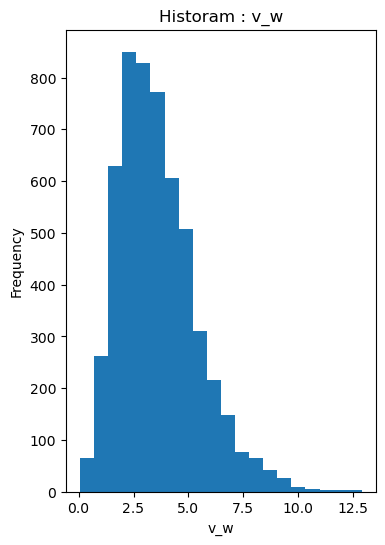

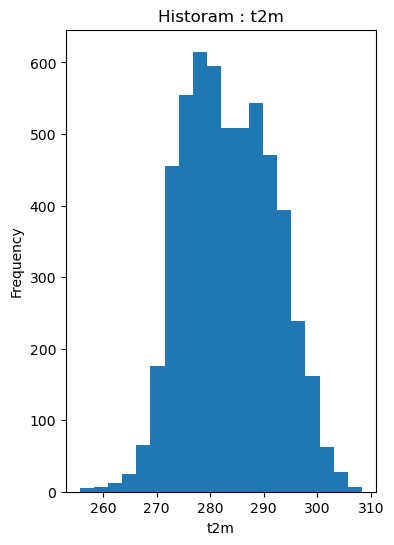

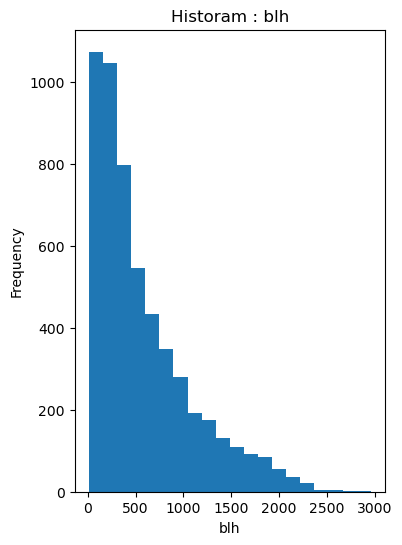

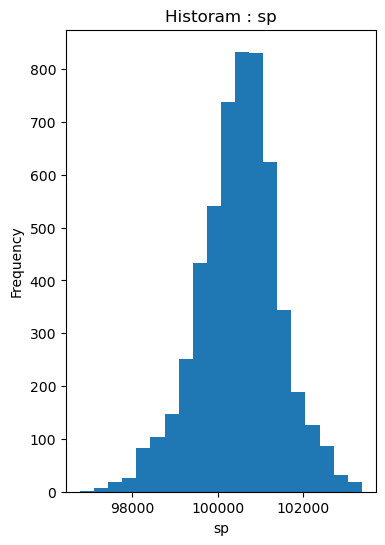

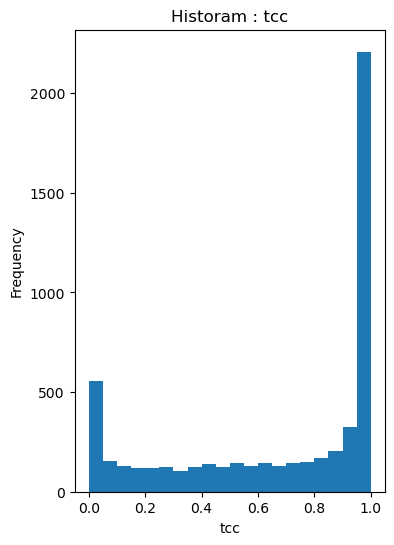

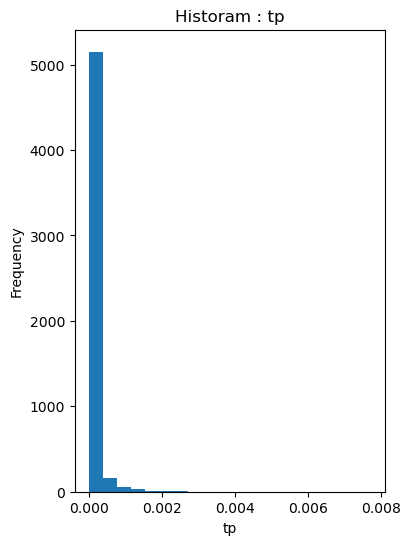

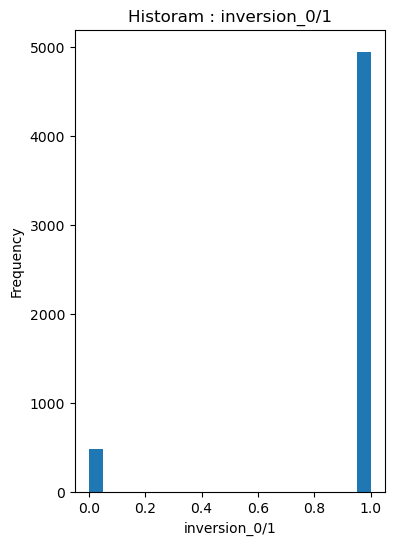

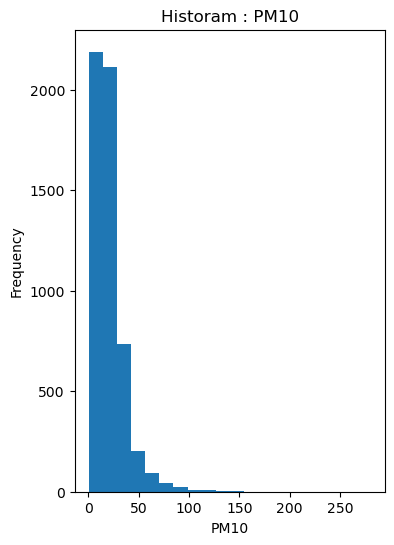

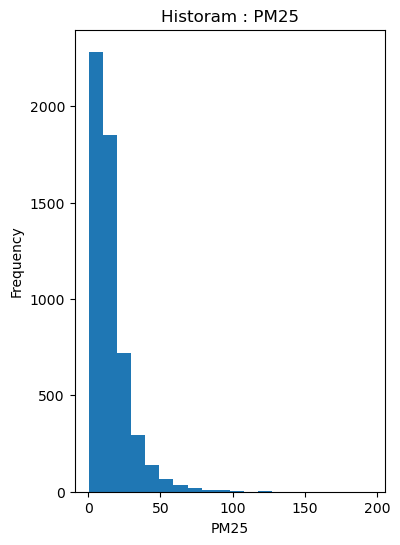

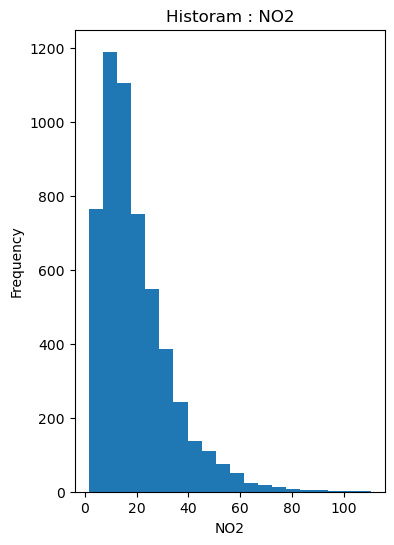

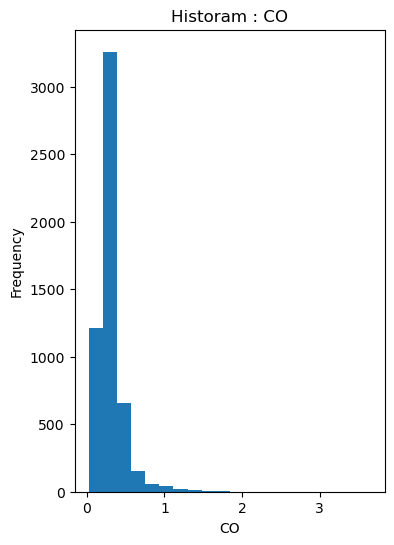

In [99]:
for c in num_col:
    plt.figure(figsize = (4,6))
    plt.hist(pz_main_df[c], bins = 20)
    plt.title(f'Historam : {c}')
    plt.xlabel(c)
    plt.ylabel('Frequency')
    plt.show()
    

In [100]:
# Wartości kolumy 'tp' (całkowitych opadów) charakteryzuja sie ogromna skośnościa,
# zamiamiana na formę binarna uprosci dataset do modelowania 
# Wprowadzamy kolumne 'tp_0/1' - 0 dla obseracji bez opadów, a 1 dla obserwacji gdy był opad

pz_main_df['tp_0/1'] = [0 if e == 0 else 1 for e in pz_main_df['tp']]

In [101]:
# usuwamy niepotrzebna kolumne 'tp'

pz_main_df = pz_main_df.drop('tp', axis=1)

In [102]:
# aktualizujemy num_col
num_col, cat_col = update_columns_ls(pz_main_df)

#### 2.3.3. Analiza Outliery

Wnioski:

Nie usuwam żadnych outlierów, gdyż sa to dane realne , zdobyte zgodnie ze wskazaniami prawidłowo działjacych stacji meteorologicznych.
Każda wartosć będaca poza zakresem IQR to rzeczywiska obserwacja, więc usunięcie ich byłoby fałszowaniem danych.


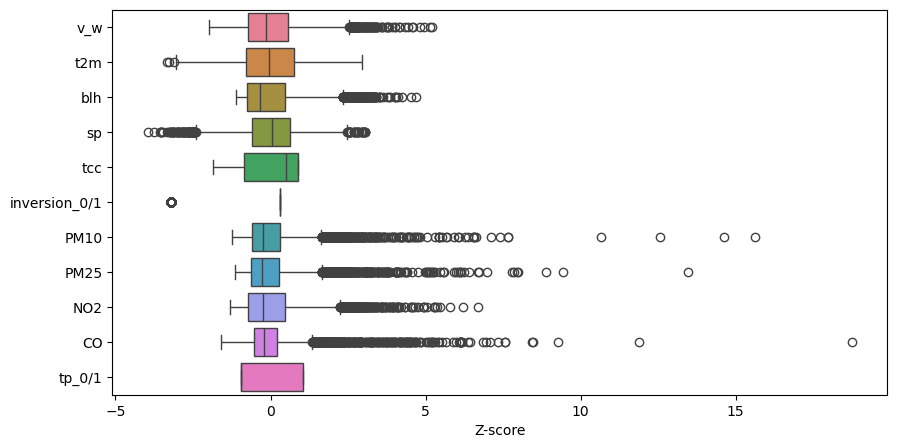

In [104]:
# tworzymy boxplot dla zmiennych z main_df do oceny wizualnej sytuacji outlierów.

num_df = pz_main_df[num_col].copy()

# przy tworzeniu box plot, stosujemy wzrór na Z-sore tj. normalizaja, standaryzacje danych (przeskalownie)
# dla wyraźniejszego pokazania na wykresie rozkładu danych po przez wizualizację statystyk pozycujnych.
plt.figure(figsize=(10,5))
sns.boxplot((num_df-num_df.mean())/num_df.std(),orient='h')
plt.xlabel('Z-score')
plt.show()

#### 2.3.4. Badanie korelacji cech numerycznych PERSONA

Korelacja Pearsona (r)

Definicja: Mierzy siłę i kierunek liniowej zależności między dwiema zmiennymi ilościowymi.

......................................................................................................................................................................................................................................


Wniosek : Z uwagi na wcześniejsza analiza czynników meteorologicznych majacych wpływ na poziom jakości powietrza na danym obszarze,
postanawiam nie usuwać, żednych z wymienionych cech numerycznych.

Ale w badaniu skuteczności modeli moze okazać się , że niektóre dane wymagaja usuniecia 

In [106]:
corr_matrix = pz_main_df.corr(numeric_only=True,method='pearson')
corr_target = corr_matrix.loc[num_col,target_col]

In [107]:
# g = sns.PairGrid(main_df['bhl'], hue='PM25')

# # Co ma być na przekątnej (np. rozkład)
# g.map_diag(sns.kdeplot, fill=True)

# # Co ma być nad przekątną (np. wykresy punktowe)
# g.map_upper(sns.scatterplot, s=10)

# # Co ma być pod przekątną (np. wykresy gęstości/regresji)
# g.map_lower(sns.kdeplot, levels=4, color=".2")

# plt.show()

In [108]:
# Korelacja ze zmiennymi cech dla PM10

corr_target['PM10'].drop(target_col).abs().sort_values(ascending=False).to_frame()

,PM10
blh,0.300624
inversion_0/1,0.278079
v_w,0.238196
t2m,0.224400
sp,0.163003
tp_0/1,0.125861
tcc,0.033921


In [109]:
# corr_target['PM25'].drop(target_col).abs().sort_values(ascending=False).to_frame()

In [110]:
# corr_target['NO2'].drop(target_col).abs().sort_values(ascending=False).to_frame()

In [111]:
# corr_target['CO'].drop(target_col).abs().sort_values(ascending=False).to_frame()

#### 2.3.5. Badanie korelacji cech kategorycznych i numerycznych.



Cecha,Pearson,Spearman,ϕk​ (Phi_k)
Typ danych,Tylko liczbowe (ciągłe),Liczbowe / Porządkowe,Mieszane (Liczby + Tekst)
Rodzaj relacji,Tylko liniowa,Monotoniczna (niekoniecznie linia),"Dowolna (nawet ""zygzaki"")"
Wrażliwość na outliery,Bardzo wysoka,Niska,Niska
Kierunek (dodatni/ujemny),Tak,Tak,Nie (tylko siła związku)
Wymagany rozkład normalny,Tak,Nie,Nie

In [114]:
# Współczynnik ϕ 2
# Definicja: Nowoczesny współczynnik oparty na teście χ2
# (Chi-kwadrat). Jest rozszerzeniem współczynnika Craméra V.
# Wartości: od 0 do 1 (nie wskazuje kierunku, tylko siłę związku).
# Przykład: Marka samochodu vs Awaryjność. Tutaj nie ma "kolejności" (marki to kategorie), a Pearson ich nie policzy.
# Kiedy najlepsza: W sytuacjach mieszanych (liczby + tekst) oraz gdy zależności są bardzo skomplikowane (np. sinusoida, gdzie Pearson pokaże 0).

corr_phik = pz_main_df.phik_matrix()


interval columns not set, guessing: ['v_w', 't2m', 'blh', 'sp', 'tcc', 'inversion_0/1', 'PM10', 'PM25', 'NO2', 'CO', 'tp_0/1']


/opt/anaconda3/lib/python3.12/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable time is large: 5433. Are you sure this is not an interval variable? Analysis for pairs of variables including time can be slow.
  warnings.warn(


<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
/var/folders/1_/28vylhx11cs54zyvgx55gyfw0000gn/T/ipykernel_91736/1165765018.py:15: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Macierz Korelacji $\phi_k$', fontsize=16)


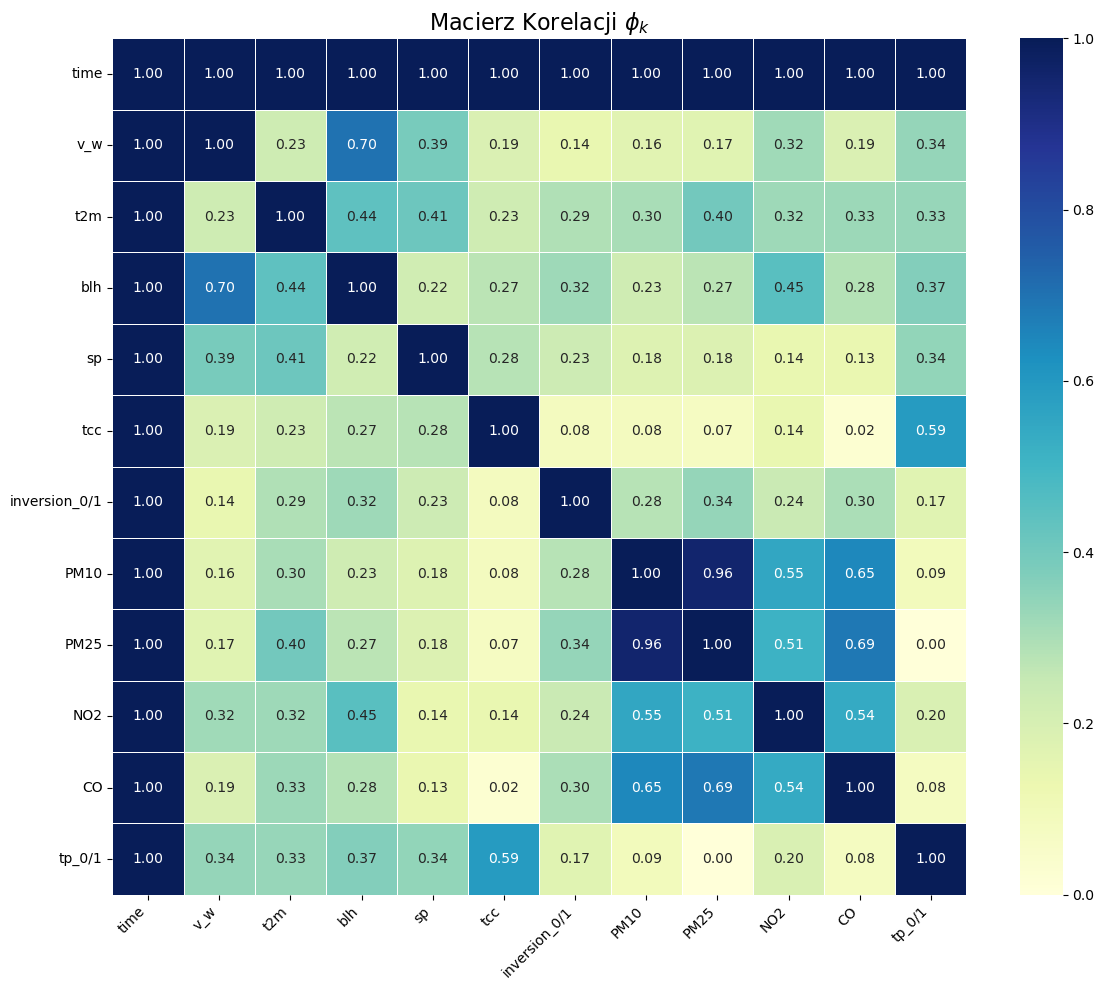

In [115]:
# Wizualizacja macierzy korelacji Phi-kwadrat

plt.figure(figsize = (12,10))
sns.heatmap(
    corr_phik, 
    annot=True,            
    fmt=".2f",            
    cmap='YlGnBu',         
    linewidths=0.5,        
    vmin=0,                
    vmax=1      
)

# 4. Dodanie tytułu i poprawienie czytelności
plt.title('Macierz Korelacji $\phi_k$', fontsize=16)
plt.xticks(rotation=45, ha='right') # Obrócenie nazw kolumn na osi X
plt.tight_layout()

# plt.show()

#### 2.3.6. Wnioski / Podsumowanie 

1. Część dancyh cech zmiennych takie jak 
- 'bhl' (wysokość warstwy granicznej) jest 
- 'tp' (całkowite opady)
Prezentuja duża skośnosc rozkładu danych. 
Należy zastostować odpowiednie transformację dla modeli liniowych , numerycznych.
2. Analiza braków danych pokazuje , że najwięcej dancyh brakuje w zmiennych celu :
- PM10 = 239
- PM25 = 239
- NO2 = 176
- CO = 83
- tp = 6
3. Analiza Outlierów pokazuje duże extrema dla kilku dancych meteorologicznych , sa to jednak rzeczywiste pomiary , dla których należy
  zachować wszysktie wartosc.
3.1. Przy mozliwości uzycie redukcji wpływów ekstrmów na działanie modeli, zostana uzyte odpowiednie parametry.


<hr style="height: 25px; background-color: #4e801f; border: none;">

## 3. Transformacja danych

### 3.1. Feature engeniering

In [121]:

# Rozbijamy 'time' na szczegóły, przypisanie do nowych kolumn wartosći - Rok / Miesiac / Dzień / Dzień_tyg / 
pz_main_df = pz_main_df.assign(
    month=pz_main_df['time'].dt.month_name(),
    year=pz_main_df['time'].dt.year,
    day=pz_main_df['time'].dt.day,
    hour=pz_main_df['time'].dt.time,
    day_of_week=pz_main_df['time'].dt.day_name())


# Po transformacji 'time' na osobne kolumny ta, zmienna nie jest już potrzbena , wiec ja usuwamy.
pz_main_df = pz_main_df.drop('time',axis=1)


# Transformacja kolumna 'hour' z datetime na string
pz_main_df['hour'] = pz_main_df['hour'].astype(str)

In [122]:
# Wprowadzamy kolumnę day_night dla zaznaczenia które pomiary sa noca a które za dania

pz_main_df['is_night'] = ['0' if e in ['00:00:00','06:00:00'] else '1' for e in pz_main_df['hour']]

In [123]:
# Wprowadzamy podział na dzień weekendowy oraz nie weekendowy , dla wskazania wiekszego ruchu drogowego, 
# przy którym wskazania tej samej pogody, moga być inne wskazania jakosci powietrza. 
day_of_weekend = ['Saturday', 'Sunday']

pz_main_df['is_weekend'] = ['1' if e in day_of_weekend else '0' for e in pz_main_df['day_of_week']]

In [124]:
# Ważnym elemntem jest sezonowość pór roku , dlatego prowadzamy nowa kolumne 'season'

season_dic = {
    'sprinig' : ['March','April','May'],
    'summer' : ['June','July','August'],
    'autum' : ['September','October','November'],
    'winter' : ['December','January','February']
}
pz_main_df['season'] = [
    'Winter' if m in ['December','January','February'] else
    'Sprinig' if m in ['March','April','May'] else
    'Summer' if m in ['June','July','August'] else
    'Autum'
    for m in pz_main_df['month']
]

In [125]:
num_col, cat_col = update_columns_ls(pz_main_df)
num_feature_col, cat_feature_col = update_feature_col(pz_main_df)
target_df, feature_df = update_target_feature_df(pz_main_df)

### 3.2. Podział train test 

In [127]:
# Dzielimy dataset , na część treningowa oraz testowa dla cech oraz celów z pz_main_df

X_train, X_test, y_train, y_test = train_test_split(
    feature_df, target_df,
    test_size=0.2,
    random_state=42
) 

In [128]:
X_train

,month,hour,day_of_week,is_night,is_weekend,season,v_w,t2m,blh,inversion_0/1,tp_0/1,year,day
5378,September,00:00:00,Thursday,0,0,Autum,4.550661,294.42822,405.755370,1,0,2024,5
1711,March,06:00:00,Friday,0,0,Sprinig,3.020459,273.90040,565.542970,1,1,2022,4
2848,December,12:00:00,Tuesday,1,0,Winter,4.303393,271.89722,999.918700,1,1,2022,13
704,June,00:00:00,Saturday,0,1,Summer,0.971361,288.49830,26.156220,1,0,2021,26
3419,May,18:00:00,Thursday,1,0,Sprinig,1.665097,287.72144,55.713364,1,0,2023,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4072,October,00:00:00,Sunday,0,1,Autum,5.519260,281.28003,1071.452900,1,0,2023,15
5581,October,18:00:00,Friday,1,0,Autum,2.911693,283.98657,159.405030,1,0,2024,25
5625,November,18:00:00,Tuesday,1,0,Autum,1.345457,275.91187,64.702255,0,0,2024,5
5806,December,00:00:00,Saturday,0,1,Winter,4.786034,276.60230,623.671900,1,1,2024,21


### 3.3. Preprocessing dla Linear Regression

#### 3.3.1. Standard Scaller 

In [131]:
# Wyznaczmy kolumny do transdormacji dla Linear Regression 
col_to_scale = [x for x in num_feature_col if x != 'inversion_0/1' and x != 'city' and x != 'time']
# dodanie metody jako zmiennej 
num_scaling = StandardScaler()

In [132]:
col_to_scale

['v_w', 't2m', 'blh', 'tp_0/1', 'year', 'day']

#### 3.3.2. Transformacja Logarytmiczna 

In [134]:
# Wyznaczamy nazwy kolumn dla których zastosowana bedzie Transformacja Logarytmiczna , 
# na podstawie analizy wykonanej w punkcie 2.3.1.
skew_ls = skew_df['features'].to_list()
col_to_logtransform = [x for x in num_feature_col if x in skew_ls and x not in target_col]
# dodanie metody jako zmiennej 
num_logtransform =  FunctionTransformer(np.log1p)

In [135]:
col_to_logtransform

['blh']

#### 3.3.3. One hot encoding

In [137]:
col_to_ohe = cat_feature_col
cat_ohe = OneHotEncoder(handle_unknown='ignore')

In [138]:
col_to_ohe

['month', 'hour', 'day_of_week', 'is_night', 'is_weekend', 'season']

### 3.4. Pipeline Preprocessing

#### 3.4.1. Linear Regression Pipeline 

In [141]:
num_311_313_prepro_LR = Pipeline(steps = [
    ('scaliing' , num_scaling),
])

num_312_prepro_LR  = Pipeline(steps = [
    ('logtrans' , num_logtransform),
])

cat_313_prepro_LR = Pipeline(steps = [
    ('onehot', cat_ohe)
])

### 3.5. Transformacja

#### 3.3.1. Transformacja Kolumn do Linear Regression

In [144]:
lr_transform = ColumnTransformer(transformers=[
    ('num_scaling+fillNaN', num_311_313_prepro_LR ,col_to_scale),
    ('num_logtrans+fillNaN', num_312_prepro_LR, col_to_scale),
    ('cat_onehot', cat_313_prepro_LR, col_to_ohe)
])

## 4. Budowanie Modeli Uczenia Maszynowego

### 4.0. Dummy Regresion 

In [147]:
target_col

['PM10', 'PM25', 'NO2', 'CO']

In [148]:
baseline_dr = DummyRegressor()

models_dr = {}

for t in target_col:
    model_dr = baseline_dr.fit(
        X_train, y_train[t],
    )
    preds_dr = model_dr.predict(X_test)
    mae_dr   = mean_absolute_error(y_test[t], preds_dr)
    rmse_dr  = np.sqrt(mean_squared_error(y_test[t], preds_dr))
    r2_dr    = r2_score(y_test[t], preds_dr)

    
    models_dr[t]  = preds_dr
    models_dr[t] = {'MAE': mae_dr, 'RMSE': rmse_dr, 'R2': r2_dr}
    print(f" POLUTION: {t} -> MAE={mae_dr:.3f}  RMSE={rmse_dr:.3f}  R²={r2_dr:.3f}")

 POLUTION: PM10 -> MAE=10.883  RMSE=16.167  R²=-0.001
 POLUTION: PM25 -> MAE=9.148  RMSE=13.376  R²=-0.001
 POLUTION: NO2 -> MAE=10.123  RMSE=13.773  R²=-0.002
 POLUTION: CO -> MAE=0.112  RMSE=0.185  R²=-0.001


### 4.1. Linear Regression

#### 4.1.1. Budowa modelu Linear Regression
Dla każdeko celu odzielnie 

In [151]:
# tworzymy pipeline dla uprzednio wykonanych dostosowania danych oraz podłaczamy model ML

baseline_lr = Pipeline([
    ('preprocess', lr_transform),
    ('model', LinearRegression())
])

In [152]:
# trenowanie modelu 

model_lr = baseline_lr.fit(X_train, y_train)
print("Modele zostały wytrenowane.")

Modele zostały wytrenowane.


#### 4.1.2. Predykcja 

In [154]:
# Wykonujemy predykcje na zbiorze testowym X (features)

y_pred_lr = model_lr.predict(X_test)

print('Predykcje zostały wykonane')

Predykcje zostały wykonane


#### 4.1.3. Metryki jakości modelu 
- MAE - średni bład bezwzględny
- RMSE - pierwiastek błędu średniokwadratowego
- R2 - procent wyjaśnienia wariancji

In [156]:
# Prezentacja metryk dla każdeko z elemetnów celu target 

results_lr = {}
for col in target_col:
    y_t = y_test[col]
    y_p = y_pred_lr[:, target_col.index(col)]
    mae  = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2   = r2_score(y_t, y_p)
    results_lr[col] = {'MAE': round(mae,3), 'RMSE': round(rmse,3), 'R2': round(r2,3)}

metrics_lr_df = pd.DataFrame(results_lr).T
metrics_lr_df

,MAE,RMSE,R2
PM10,8.753,13.101,0.343
PM25,6.979,10.356,0.400
NO2,7.202,10.057,0.466
CO,0.092,0.150,0.342


In [157]:
# Walidacja skośna (Cross-Validation) 
    # Dzieli Twój zbiór danych na 5 równych części (bo cv=5). Następnie:
    # Trenuje model na 4 częściach, a testuje na 1 (pozostałej).
    # Powtarza to 5 razy, za każdym razem wybierając inną część jako testową
# R2 (współczynnik determinacji) - mowi jaki procent zminności celu został wyjaśniony przez model.

for col in target_col:
    cv_scores = cross_val_score(baseline_lr, feature_df, target_df[col],
                                cv=5, scoring='r2')
    print(f"{col}: CV R² = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

PM10: CV R² = 0.188 ± 0.107
PM25: CV R² = 0.339 ± 0.064
NO2: CV R² = 0.141 ± 0.166
CO: CV R² = 0.264 ± 0.050


#### 4.1.4 Wizualizacja wyników

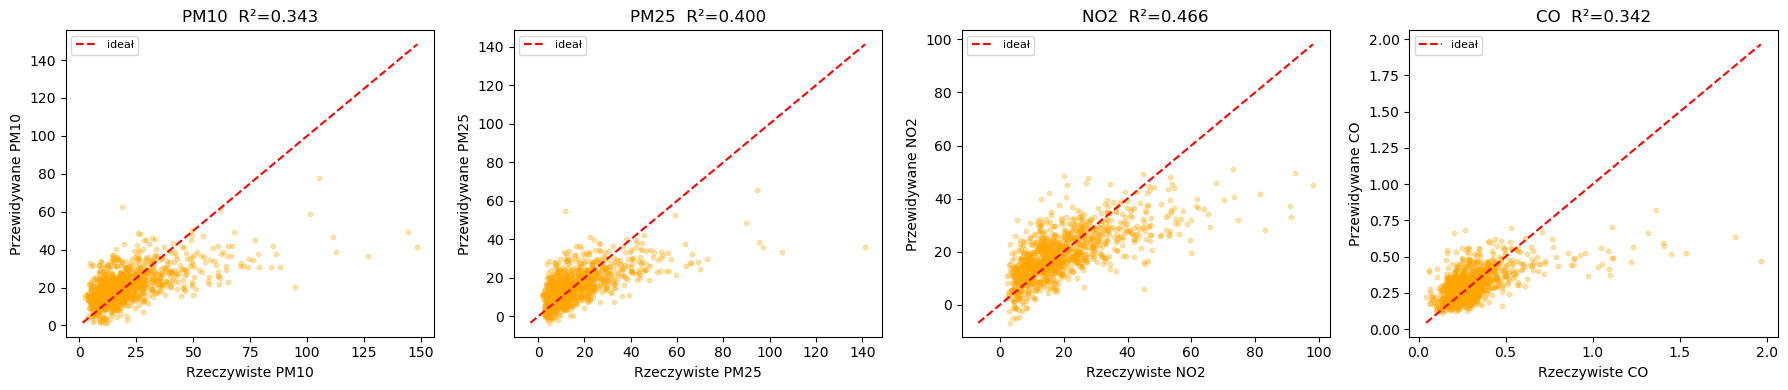

In [159]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(target_col):
    y_t = y_test[col].values
    y_p = y_pred_lr[:, i]
    axes[i].scatter(y_t, y_p, alpha=0.3, s=10, color='orange')
    lim = [min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())]
    axes[i].plot(lim, lim, 'r--', linewidth=1.5, label='ideał')
    axes[i].set_xlabel(f'Rzeczywiste {col}')
    axes[i].set_ylabel(f'Przewidywane {col}')
    axes[i].set_title(f'{col}  R²={r2_score(y_t,y_p):.3f}')
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.show()

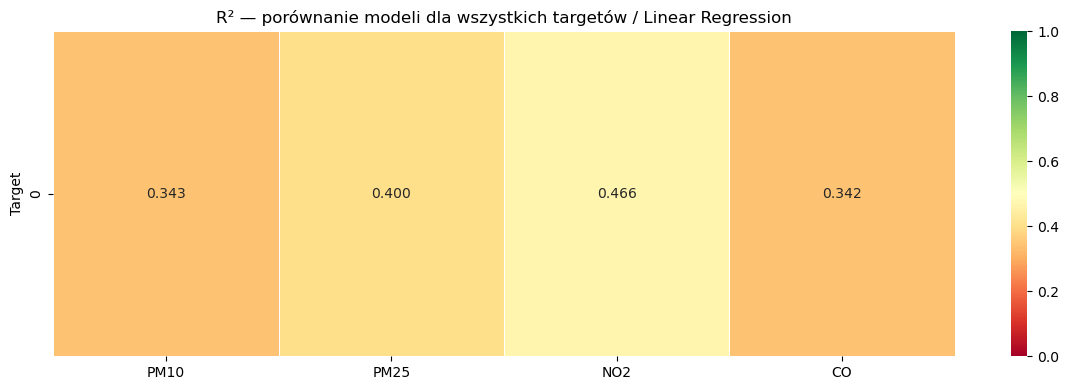

In [160]:
r2_matrix_lr = pd.DataFrame({
    name: metric_tab['R2'] for name, metric_tab in results_lr.items()
},index=[0])
plt.figure(figsize=(12, 4))
sns.heatmap(r2_matrix_lr, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5)
plt.title('R² — porównanie modeli dla wszystkich targetów / Linear Regression')
plt.ylabel('Target')
plt.tight_layout()
plt.show()

### 4.2. CatBoost

#### 4.2.1. Budowa Modelu CatBoost

In [163]:
# Słownik pozwoli zapisać model_cb dla każdego target z osobna.
models_cb = {}

for t in target_col:

    models_cb[t] = CatBoostRegressor(
        iterations=1000,
        # liczba drzew budowanych przez boosting: więcej iteracji to większa dokłdnosć i overfiting. [Zakres 100-10000]
        
        learning_rate=0.05,
        # Szybkość uczenia modelu : tempo optymalizaji i stabilnosc uczenia / wolniej to dokładniej. [Zakres 0.01-0.3]

        depth=10,
        # Głębokość drzewa decyzyjnego:  złożoność modelu  / zwiększa overfiting / wyższa wartosć model dokłdny. [Zakres 1-16]
        
        l2_leaf_reg=10,
        # Regularyzacja L2 :  Chroni przed overfitingiem wyższa wartosć model ostrożny. [Opcje: RMSE/MAE/Huber/Quantile/LogCosh/Poisson]

        min_data_in_leaf=5,
        # Min liczba próbek w liściu drzewa: im mnniej tym bardziej dopasowany im wiecej tym stabilny 
        
        loss_function='RMSE',
        # Funkcja błędu używana podczas treningu im mniejsze RMSE tym lepszy model.
        
        eval_metric='R2',
        # Metryka monitorowania podczas walidacji 
        
        nan_mode='Min',
        # sposób obsługi NaN
        
        random_seed=42,
        # Ustawia losowość, wyniki sa powtarzale
        
        early_stopping_rounds=50,
        # jeśli model nie poprawi wyniku prze X iteracji model zostanie zatrzymany

        use_best_model=True,
        # Zachowuje najlepszy model, a nie ostatni.
        
        verbose=100
        # Co ile iteracji ma byc wypisywany log treningu
    )

#### 4.2.2. Trenowanie modelu CatBoost

In [165]:
# pętla pozwala przypisać każdy traning na dancyh testowych dla osobnego celu 'target'

for t in target_col:

    print("="*60)
    print(f"Trenowanie modelu dla: {t}")
    print("="*60)

    models_cb[t].fit(
        X_train,
        y_train[t],

        cat_features=cat_col,

        eval_set=(
            X_test,
            y_test[t]
        )
    )

Trenowanie modelu dla: PM10
0:	learn: 0.0223334	test: 0.0223274	best: 0.0223274 (0)	total: 63.5ms	remaining: 1m 3s
100:	learn: 0.5285650	test: 0.4349972	best: 0.4349972 (100)	total: 1.7s	remaining: 15.2s
200:	learn: 0.6417619	test: 0.4863279	best: 0.4863279 (200)	total: 3.75s	remaining: 14.9s
300:	learn: 0.7002910	test: 0.5059279	best: 0.5059279 (300)	total: 6.21s	remaining: 14.4s
400:	learn: 0.7438690	test: 0.5206488	best: 0.5207896 (399)	total: 9.4s	remaining: 14s
500:	learn: 0.7774428	test: 0.5308403	best: 0.5308403 (500)	total: 11.7s	remaining: 11.7s
600:	learn: 0.8051676	test: 0.5373499	best: 0.5374245 (596)	total: 13.8s	remaining: 9.19s
700:	learn: 0.8290351	test: 0.5442793	best: 0.5442793 (700)	total: 16.4s	remaining: 7.01s
800:	learn: 0.8462975	test: 0.5489316	best: 0.5489585 (798)	total: 19.6s	remaining: 4.87s
900:	learn: 0.8679558	test: 0.5569654	best: 0.5569654 (900)	total: 22.7s	remaining: 2.49s
999:	learn: 0.8851904	test: 0.5630549	best: 0.5630549 (999)	total: 24.7s	remain

#### 4.2.3. Predykcja

In [167]:
predictions_cb = {}

for t in target_col:

    predictions_cb[t] = models_cb[t].predict(X_test)

    print(
        f"{t}: wykonano "
        f"{len(predictions_cb[t])} predykcji"
    )

PM10: wykonano 1087 predykcji
PM25: wykonano 1087 predykcji
NO2: wykonano 1087 predykcji
CO: wykonano 1087 predykcji


#### 4.2.4. Metryki dla GB

In [169]:
results_cb = {}

for col in target_col:
# Metryka MAE (Mean Absolute Error - Średni Bład Bezwzględny)
    mae = mean_absolute_error(
        y_test[col],
        predictions_cb[col]
    )
# Metryka RMSE (Root Squared Error - Pierwiastek Średniego Błędu Kwadratowegoo) 
    rmse = np.sqrt(
        mean_squared_error(
            y_test[col],
            predictions_cb[col]
        )
    )
# Metryka r2 (Współczynnik Determinacji) 
    r2 = r2_score(
        y_test[col],
        predictions_cb[col]
    )
    results_cb[col] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

metrics_cb_df = pd.DataFrame(results_cb).T
metrics_cb_df

,MAE,RMSE,R2
PM10,6.993173,10.683754,0.563055
PM25,5.583382,8.437219,0.601647
NO2,5.232095,7.804223,0.678328
CO,0.065410,0.117826,0.594462


#### 4.2.5. Wizualizację metryk 

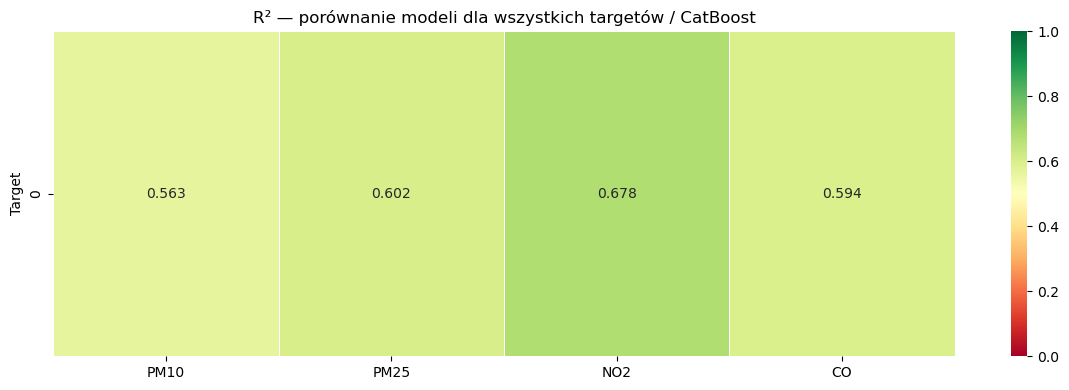

In [171]:
# porównanie wyników modelu przez metrykę R2 po przez wizualziajcę na heatmapie.

r2_matrix_gb = pd.DataFrame({
    name: metrics_cb_tab['R2'] for name, metrics_cb_tab in results_cb.items()
},index=[0])
plt.figure(figsize=(12, 4))
sns.heatmap(r2_matrix_gb, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5,)
plt.title('R² — porównanie modeli dla wszystkich targetów / CatBoost')
plt.ylabel('Target')
plt.tight_layout()
plt.show()

In [172]:
predictions_cb = {}

for i, t in enumerate(target_col):
    predictions_cb[t] = models_cb[t].predict(X_test)

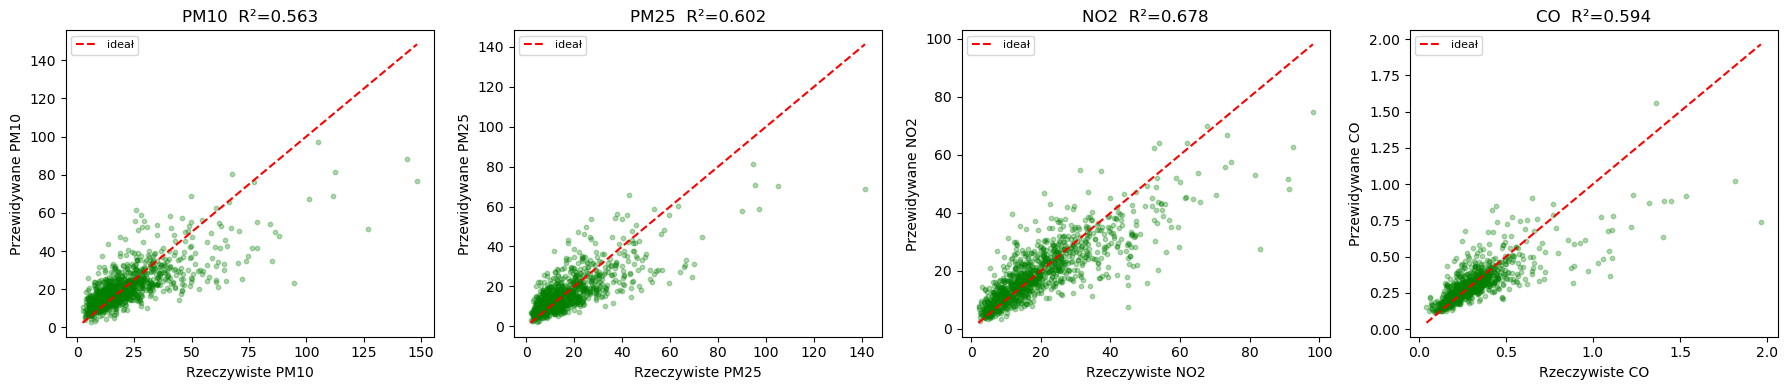

In [173]:
# Wykres polczenie wyników predykcji wobec wartości rzeczywistych.

ig, axes = plt.subplots(1, len(target_col), figsize=(18, 4))

for i, col in enumerate(target_col):

    y_t = y_test[col].values
    y_p = predictions_cb[col]

    axes[i].scatter(y_t, y_p, alpha=0.3, s=10, color='green')

    lim = [
        min(y_t.min(), y_p.min()),
        max(y_t.max(), y_p.max())
    ]

    axes[i].plot(lim, lim, 'r--', linewidth=1.5, label='ideał')

    axes[i].set_xlabel(f'Rzeczywiste {col}')
    axes[i].set_ylabel(f'Przewidywane {col}')

    axes[i].set_title(f'{col}  R²={r2_score(y_t, y_p):.3f}')

    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Wnioski 


Celem projektu było porównanie skuteczności modeli **Linear Regression** oraz **CatBoost Regressor** w prognozowaniu stężeń zanieczyszczeń powietrza (**PM10, PM2.5, NO₂ oraz CO**) na podstawie danych meteorologicznych.

Przeprowadzona analiza wykazała, że model **CatBoost** osiągnął lepsze wyniki dla wszystkich analizowanych zmiennych. Potwierdzają to wyższe wartości współczynnika determinacji **R²** oraz niższe wartości błędów **MAE** i **RMSE** w porównaniu z regresją liniową.

Najlepsze rezultaty uzyskano dla predykcji stężenia **NO₂**, gdzie model CatBoost osiągnął wartość **R² = 0.678**, natomiast największą poprawę względem regresji liniowej zaobserwowano dla zmiennych **CO** oraz **PM10**.

Uzyskane wyniki wskazują, że zależności pomiędzy warunkami meteorologicznymi a poziomem zanieczyszczeń mają charakter nieliniowy, dlatego model CatBoost, oparty na metodzie gradient boosting, skuteczniej odwzorowuje występujące w danych zależności niż klasyczna regresja liniowa.

Na podstawie przeprowadzonych eksperymentów można stwierdzić, że **CatBoost Regressor stanowi bardziej efektywne narzędzie do prognozowania jakości powietrza na podstawie danych meteorologicznych**, zapewniając wyższą dokładność i lepszą zdolność generalizacji na danych testowych.



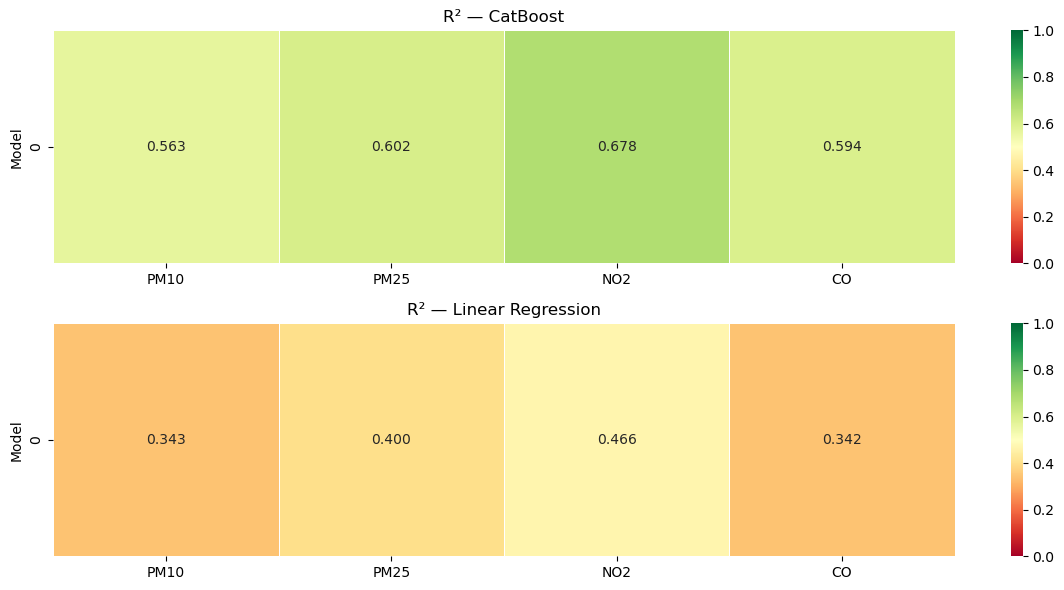

In [176]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 6)
)

# CatBoost
sns.heatmap(
    r2_matrix_gb,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=axes[0]
)

axes[0].set_title('R² — CatBoost')
axes[0].set_ylabel('Model')

# Linear Regression
sns.heatmap(
    r2_matrix_lr,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=axes[1]
)

axes[1].set_title('R² — Linear Regression')
axes[1].set_ylabel('Model')

plt.tight_layout()
plt.show()